Bölüm: 100	Ortalama Skor (Son 100): 18.82
Bölüm: 200	Ortalama Skor (Son 100): 31.39
Bölüm: 300	Ortalama Skor (Son 100): 71.23
Bölüm: 400	Ortalama Skor (Son 100): 174.79
Bölüm: 500	Ortalama Skor (Son 100): 218.10
Bölüm: 600	Ortalama Skor (Son 100): 286.36
Bölüm: 700	Ortalama Skor (Son 100): 420.44
Bölüm: 800	Ortalama Skor (Son 100): 440.15
Bölüm: 900	Ortalama Skor (Son 100): 454.49
Bölüm: 1000	Ortalama Skor (Son 100): 447.57


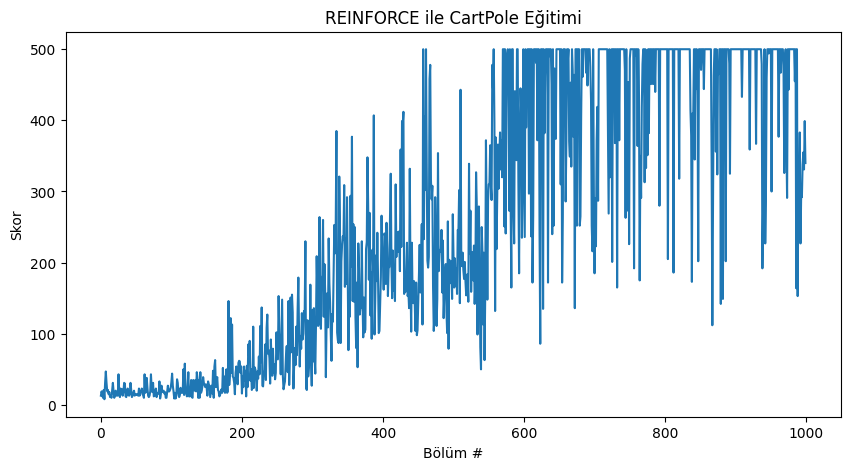

In [1]:
import gymnasium as gym
import torch
import numpy as np
import random
import os
import sys
from collections import deque
import matplotlib.pyplot as plt

# --- Proje Kök Dizinini Python Path'e Ekleme ---
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# --- Kendi Ajan Modülümüzü İçe Aktarma ---
from src.agents.simple_pg import ReinforceAgent

# --- Kurulum ve Seed Ayarları ---
def set_seed(seed_value=42):
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)
    np.random.seed(seed_value)
    random.seed(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# --- Ortamı Oluşturma ---
env = gym.make("CartPole-v1")
obs_space_size = env.observation_space.shape[0]
action_space_size = env.action_space.n

# --- Ajanı Oluşturma ---
agent = ReinforceAgent(obs_space_size, action_space_size, device)

# --- Eğitim Parametreleri ---
total_episodes = 1000
print_interval = 100
scores_deque = deque(maxlen=100) # Son 100 bölümün skorlarını tutmak için
scores = []

# --- Ana Eğitim Döngüsü ---
for episode in range(1, total_episodes + 1):
    state, _ = env.reset()
    episode_reward = 0
    
    # Adım 1: Etkileşimde Bulun ve Deneyimi Topla (Interact & Store)
    while True:
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        
        agent.rewards.append(reward)
        episode_reward += reward
        state = next_state
        
        if terminated or truncated:
            break
            
    # Adım 2: Politikayı Güncelle (Update)
    # Bölüm bittikten sonra, toplanan deneyimlerle ağı güncelliyoruz.
    agent.update_policy()
    
    # Loglama
    scores_deque.append(episode_reward)
    scores.append(episode_reward)
    
    if episode % print_interval == 0:
        print(f"Bölüm: {episode}\tOrtalama Skor (Son 100): {np.mean(scores_deque):.2f}")

env.close()

# --- Sonuçları Görselleştirme ---
plt.figure(figsize=(10, 5))
plt.plot(np.arange(len(scores)), scores)
plt.ylabel('Skor')
plt.xlabel('Bölüm #')
plt.title('REINFORCE ile CartPole Eğitimi')
plt.show()
